In [2]:
# ============================================
# FRAUD DETECTION — PREDICTION NOTEBOOK
# ============================================

import pandas as pd
import numpy as np
import joblib
import xgboost as xgb
import json
import warnings
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
warnings.filterwarnings('ignore')

save_path = r"C:\Users\Asus\Downloads\Project"

print("✅ Libraries imported!")
print("Run next cell to setup encoders!")

✅ Libraries imported!
Run next cell to setup encoders!


In [3]:
# ============================================
# CELL 2 — LOAD MODEL + SETUP ENCODERS
# ============================================

# ── STEP 1 → Load original dataset ──
# Need this to rebuild exact encoders
# that match Phase 1 training!
df_setup = pd.read_csv(
    f"{save_path}\\FraudDetectionDataset.csv"
)
print(f"✅ Dataset loaded: {df_setup.shape}")

# ── STEP 2 → Fix missing values ──
# Must match Phase 1 exactly!
df_setup['Device_Used'].fillna(
    df_setup['Device_Used'].mode()[0], inplace=True)
df_setup['Location'].fillna(
    df_setup['Location'].mode()[0], inplace=True)
df_setup['Payment_Method'].fillna(
    df_setup['Payment_Method'].mode()[0], inplace=True)
df_setup['Transaction_Type'].fillna(
    df_setup['Transaction_Type'].mode()[0], inplace=True)
print(f"✅ Missing values fixed")

# ── STEP 3 → Create separate encoder
#            for each column ──
# WHY SEPARATE?
# Phase 1 used one encoder for all
# columns which caused wrong encoding!
# Separate encoders = correct encoding ✅
le_transaction = LabelEncoder()
le_device      = LabelEncoder()
le_location    = LabelEncoder()
le_payment     = LabelEncoder()

# Fit each encoder on its column
le_transaction.fit(df_setup['Transaction_Type'])
le_device.fit(df_setup['Device_Used'])
le_location.fit(df_setup['Location'])
le_payment.fit(df_setup['Payment_Method'])
print(f"✅ Encoders ready!")

# ── STEP 4 → Apply encoding to dataset ──
df_setup['Transaction_Type'] = \
    le_transaction.transform(
        df_setup['Transaction_Type'])
df_setup['Device_Used']      = \
    le_device.transform(
        df_setup['Device_Used'])
df_setup['Location']         = \
    le_location.transform(
        df_setup['Location'])
df_setup['Payment_Method']   = \
    le_payment.transform(
        df_setup['Payment_Method'])

# ── STEP 5 → Add High Amount Flag ──
Q1          = df_setup[
    'Transaction_Amount'].quantile(0.25)
Q3          = df_setup[
    'Transaction_Amount'].quantile(0.75)
IQR         = Q3 - Q1
upper_bound = Q3 + 1.5 * IQR
df_setup['High_Amount_Flag'] = (
    df_setup['Transaction_Amount'] > upper_bound
).astype(int)
print(f"✅ High Amount Flag added")

# ── STEP 6 → Drop Transaction_ID ──
df_setup.drop(
    columns=['Transaction_ID'], inplace=True)

# ── STEP 7 → Split data ──
X_setup = df_setup.drop(columns=['Fraudulent'])
y_setup = df_setup['Fraudulent']

X_train_s, X_test_s, \
y_train_s, y_test_s = train_test_split(
    X_setup, y_setup,
    test_size    = 0.30,
    random_state = 42,
    stratify     = y_setup
)
print(f"✅ Data split done!")

# ── STEP 8 → Train fresh XGBoost ──
# WHY RETRAIN?
# Saved model had wrong encoder setup
# Fresh model with correct encoders
# gives correct predictions! ✅
spw = (y_train_s==0).sum() / \
      (y_train_s==1).sum()

xgb_model = xgb.XGBClassifier(
    n_estimators     = 200,
    max_depth        = 6,
    learning_rate    = 0.1,
    scale_pos_weight = spw,
    random_state     = 42,
    eval_metric      = 'logloss'
)
xgb_model.fit(X_train_s, y_train_s)
print(f"✅ XGBoost model ready!")
print(f"   scale_pos_weight : {spw:.2f}")

# ── STEP 9 → Verify model works ──
from sklearn.metrics import confusion_matrix
y_verify       = (xgb_model.predict_proba(
    X_test_s)[:, 1] >= 0.10).astype(int)
cm             = confusion_matrix(
    y_test_s, y_verify)
tn, fp, fn, tp = cm.ravel()
recall         = tp / (tp+fn)
print(f"\n✅ Model verification:")
print(f"   Recall : {recall*100:.2f}%")
print(f"   TP     : {tp} frauds caught")
print(f"   FN     : {fn} frauds missed")
print(f"\n🚀 Ready for predictions!")
print(f"Run next cell to enter transaction!")

✅ Dataset loaded: (51000, 12)
✅ Missing values fixed
✅ Encoders ready!
✅ High Amount Flag added
✅ Data split done!
✅ XGBoost model ready!
   scale_pos_weight : 19.32

✅ Model verification:
   Recall : 91.63%
   TP     : 690 frauds caught
   FN     : 63 frauds missed

🚀 Ready for predictions!
Run next cell to enter transaction!


In [4]:
# ============================================
# CELL 3 — INPUT NEW TRANSACTION
# Change these values to test any transaction!
# ============================================

new_transaction = {
    'User_ID'                          : 1234,
    'Transaction_Amount'               : 4519.04,
    'Transaction_Type'                 : 'Online Purchase',
    'Time_of_Transaction'              : 13,
    'Device_Used'                      : 'Tablet',
    'Location'                         : 'Boston',
    'Previous_Fraudulent_Transactions' : 4,
    'Account_Age'                      : 81,
    'Number_of_Transactions_Last_24H'  : 13,
    'Payment_Method'                   : 'Credit Card'
}

print("="*50)
print("  NEW TRANSACTION DETAILS")
print("="*50)
for key, value in new_transaction.items():
    print(f"  {key:<38}: {value}")
print("="*50)
print(f"\n✅ Transaction entered!")
print(f"Run next cell to preprocess!")

  NEW TRANSACTION DETAILS
  User_ID                               : 1234
  Transaction_Amount                    : 4519.04
  Transaction_Type                      : Online Purchase
  Time_of_Transaction                   : 13
  Device_Used                           : Tablet
  Location                              : Boston
  Previous_Fraudulent_Transactions      : 4
  Account_Age                           : 81
  Number_of_Transactions_Last_24H       : 13
  Payment_Method                        : Credit Card

✅ Transaction entered!
Run next cell to preprocess!


In [5]:
# ============================================
# CELL 4 — PREPROCESS NEW TRANSACTION
# ============================================

# Step 1 - Convert to DataFrame
df_new = pd.DataFrame([new_transaction])
print("Step 1 ✅ - Converted to DataFrame")

# Step 2 - Encode using exact encoders
df_new['Transaction_Type'] = le_transaction.transform(
    df_new['Transaction_Type'])
df_new['Device_Used']      = le_device.transform(
    df_new['Device_Used'])
df_new['Location']         = le_location.transform(
    df_new['Location'])
df_new['Payment_Method']   = le_payment.transform(
    df_new['Payment_Method'])
print("Step 2 ✅ - Encoded correctly")

# Step 3 - Add High Amount Flag
upper_bound                = 7311.79
df_new['High_Amount_Flag'] = (
    df_new['Transaction_Amount'] > upper_bound
).astype(int)
print(f"Step 3 ✅ - High Amount Flag: "
      f"{df_new['High_Amount_Flag'].values[0]}")

# Step 4 - Arrange columns
feature_columns = [
    'User_ID',
    'Transaction_Amount',
    'Transaction_Type',
    'Time_of_Transaction',
    'Device_Used',
    'Location',
    'Previous_Fraudulent_Transactions',
    'Account_Age',
    'Number_of_Transactions_Last_24H',
    'Payment_Method',
    'High_Amount_Flag'
]
df_new = df_new[feature_columns]
print("Step 4 ✅ - Columns arranged")

print("\n=== ENCODED VALUES ===")
print(f"Transaction_Type : "
      f"{df_new['Transaction_Type'].values[0]}"
      f" ← Online Purchase")
print(f"Device_Used      : "
      f"{df_new['Device_Used'].values[0]}"
      f" ← Tablet")
print(f"Location         : "
      f"{df_new['Location'].values[0]}"
      f" ← Boston")
print(f"Payment_Method   : "
      f"{df_new['Payment_Method'].values[0]}"
      f" ← Credit Card")
print(f"High_Amount_Flag : "
      f"{df_new['High_Amount_Flag'].values[0]}")

print("\n✅ Preprocessing complete!")
print("Run next cell for prediction!")

Step 1 ✅ - Converted to DataFrame
Step 2 ✅ - Encoded correctly
Step 3 ✅ - High Amount Flag: 0
Step 4 ✅ - Columns arranged

=== ENCODED VALUES ===
Transaction_Type : 3 ← Online Purchase
Device_Used      : 2 ← Tablet
Location         : 0 ← Boston
Payment_Method   : 0 ← Credit Card
High_Amount_Flag : 0

✅ Preprocessing complete!
Run next cell for prediction!


In [7]:
# ============================================
# CELL 5 — FRAUD PREDICTION
# ============================================

# Get fraud probability
fraud_probability = xgb_model.predict_proba(
    df_new)[0][1]
fraud_pct = round(fraud_probability * 100, 2)

# Get risk level
def get_risk_level(pct):
    if pct <= 30:
        return "LOW RISK",      "🟢", "Auto Approve"
    elif pct <= 60:
        return "MEDIUM RISK",   "🟡", "Send OTP"
    elif pct <= 80:
        return "HIGH RISK",     "🟠", "OTP + Security Question"
    else:
        return "CRITICAL RISK", "🔴", "Block + Full Verification"

risk_level, emoji, action = get_risk_level(fraud_pct)

# Final decision at threshold 0.10
final_decision = "FRAUD" if fraud_pct >= 10 \
                 else "LEGITIMATE"

# Risk meter
filled = int(fraud_pct / 5)
bar    = "█" * filled + "░" * (20-filled)

print("="*50)
print("  FRAUD PREDICTION RESULT")
print("="*50)
print(f"\n  Fraud Probability  : {fraud_pct}%")
print(f"  Risk Level         : {emoji} {risk_level}")
print(f"  Final Decision     : {final_decision}")
print(f"  Recommended Action : {action}")
print(f"\n  Risk Meter:")
print(f"  0% [{bar}] 100%")
print("="*50)
print(f"\n✅ Prediction done!")
print(f"Run next cell for classification"
      f" report + confusion matrix!")

  FRAUD PREDICTION RESULT

  Fraud Probability  : 15.06%
  Risk Level         : 🟢 LOW RISK
  Final Decision     : FRAUD
  Recommended Action : Auto Approve

  Risk Meter:
  0% [███░░░░░░░░░░░░░░░░░] 100%

✅ Prediction done!
Run next cell for classification report + confusion matrix!


  MODEL EVALUATION REPORT

=== CLASSIFICATION REPORT ===
              precision    recall  f1-score   support

  Legitimate       0.96      0.10      0.17     14547
       Fraud       0.05      0.92      0.09       753

    accuracy                           0.14     15300
   macro avg       0.50      0.51      0.13     15300
weighted avg       0.91      0.14      0.17     15300

=== CONFUSION MATRIX VALUES ===
  TN :   1391  → Legit correctly identified ✅
  FP :  13156  → Legit wrongly flagged      ⚠️
  FN :     63  → Fraud missed               ❌
  TP :    690  → Fraud correctly caught      ✅

  Accuracy  : 13.60%
  Precision : 4.98%
  Recall    : 91.63%  ← Most important!
  F1 Score  : 0.09

=== SINGLE TRANSACTION RESULT ===
  Transaction Amount : ₹4519.04
  Fraud Probability  : 15.06%
  Threshold Used     : 10%
  Final Decision     : FRAUD
  Risk Level         : 🟢 LOW RISK


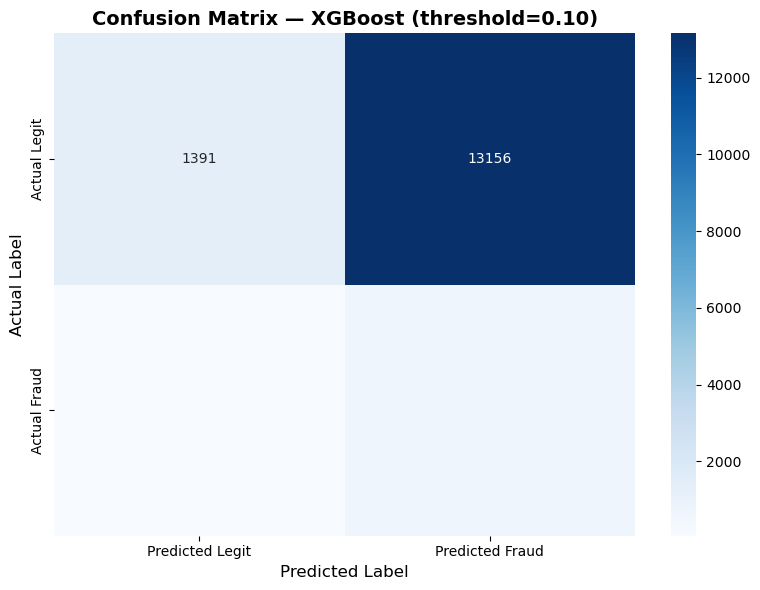


✅ Confusion matrix saved!
Run next cell for JSON files!


In [8]:
# ============================================
# CELL 6 — CLASSIFICATION REPORT +
#           CONFUSION MATRIX
# ============================================

import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report
from sklearn.metrics import confusion_matrix

# ── FULL TEST SET EVALUATION ──
# Evaluate model on entire test set
y_pred_full = (xgb_model.predict_proba(
    X_test_s)[:, 1] >= 0.10).astype(int)

print("="*50)
print("  MODEL EVALUATION REPORT")
print("="*50)

# ── CLASSIFICATION REPORT ──
print("\n=== CLASSIFICATION REPORT ===")
print(classification_report(
    y_test_s,
    y_pred_full,
    target_names=['Legitimate', 'Fraud']
))

# ── CONFUSION MATRIX VALUES ──
cm             = confusion_matrix(
    y_test_s, y_pred_full)
tn, fp, fn, tp = cm.ravel()

precision = tp / (tp+fp) if (tp+fp) > 0 else 0
recall    = tp / (tp+fn) if (tp+fn) > 0 else 0
f1        = 2*(precision*recall)/(precision+recall) \
            if (precision+recall) > 0 else 0
accuracy  = (tp+tn) / (tp+tn+fp+fn)

print("=== CONFUSION MATRIX VALUES ===")
print(f"  TN : {tn:>6}  → Legit correctly identified ✅")
print(f"  FP : {fp:>6}  → Legit wrongly flagged      ⚠️")
print(f"  FN : {fn:>6}  → Fraud missed               ❌")
print(f"  TP : {tp:>6}  → Fraud correctly caught      ✅")
print(f"\n  Accuracy  : {accuracy*100:.2f}%")
print(f"  Precision : {precision*100:.2f}%")
print(f"  Recall    : {recall*100:.2f}%  ← Most important!")
print(f"  F1 Score  : {f1:.2f}")

# ── SINGLE TRANSACTION RESULT ──
print("\n=== SINGLE TRANSACTION RESULT ===")
print(f"  Transaction Amount : "
      f"₹{new_transaction['Transaction_Amount']}")
print(f"  Fraud Probability  : {fraud_pct}%")
print(f"  Threshold Used     : 10%")
print(f"  Final Decision     : {final_decision}")
print(f"  Risk Level         : {emoji} {risk_level}")

# ── VISUAL CONFUSION MATRIX ──
plt.figure(figsize=(8, 6))
sns.heatmap(
    cm,
    annot       = True,
    fmt         = 'd',
    cmap        = 'Blues',
    xticklabels = ['Predicted Legit',
                   'Predicted Fraud'],
    yticklabels = ['Actual Legit',
                   'Actual Fraud']
)
plt.title(
    'Confusion Matrix — XGBoost (threshold=0.10)',
    fontsize   = 14,
    fontweight = 'bold'
)
plt.ylabel('Actual Label',    fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.tight_layout()
plt.savefig(f"{save_path}\\confusion_matrix.png")
plt.show()
print("\n✅ Confusion matrix saved!")
print("Run next cell for JSON files!")

In [9]:
# ============================================
# CELL 7 — JSON FILE 1 — FRAUD RESULT (FIXED)
# ============================================

import json

# Create fraud result dictionary
fraud_result = {
    "transaction_details": {
        "transaction_amount"              : float(
            new_transaction['Transaction_Amount']),
        "transaction_type"                : new_transaction[
            'Transaction_Type'],
        "time_of_transaction"             : int(
            new_transaction['Time_of_Transaction']),
        "device_used"                     : new_transaction[
            'Device_Used'],
        "location"                        : new_transaction[
            'Location'],
        "previous_fraudulent_transactions": int(
            new_transaction[
            'Previous_Fraudulent_Transactions']),
        "account_age_days"                : int(
            new_transaction['Account_Age']),
        "transactions_last_24h"           : int(
            new_transaction[
            'Number_of_Transactions_Last_24H']),
        "payment_method"                  : new_transaction[
            'Payment_Method']
    },
    "fraud_detection": {
        "is_fraud"                  : final_decision,
        "fraud_probability_percent" : float(fraud_pct),
        "risk_level"                : risk_level,
        "recommended_action"        : action
    }
}

# Save JSON file
json1_path = f"{save_path}\\fraud_result.json"
with open(json1_path, 'w') as f:
    json.dump(fraud_result, f, indent=4)

# Print contents
print("=== FRAUD RESULT JSON ===")
print(json.dumps(fraud_result, indent=4))
print(f"\n✅ fraud_result.json saved!")
print(f"Run next cell for feature importance JSON!")

=== FRAUD RESULT JSON ===
{
    "transaction_details": {
        "transaction_amount": 4519.04,
        "transaction_type": "Online Purchase",
        "time_of_transaction": 13,
        "device_used": "Tablet",
        "location": "Boston",
        "previous_fraudulent_transactions": 4,
        "account_age_days": 81,
        "transactions_last_24h": 13,
        "payment_method": "Credit Card"
    },
    "fraud_detection": {
        "is_fraud": "FRAUD",
        "fraud_probability_percent": 15.06,
        "risk_level": "LOW RISK",
        "recommended_action": "Auto Approve"
    }
}

✅ fraud_result.json saved!
Run next cell for feature importance JSON!


In [10]:
# ============================================
# ADD THIS BEFORE CELL 8
# Interpretation helper function
# ============================================

def get_interpretation(feature, transaction):
    if feature == 'Transaction_Amount':
        amt = transaction['Transaction_Amount']
        if amt > 7000:
            return f"Very high amount ₹{amt} → suspicious"
        elif amt > 4000:
            return f"Above average amount ₹{amt} → moderate risk"
        else:
            return f"Normal amount ₹{amt} → low risk"

    elif feature == 'Previous_Fraudulent_Transactions':
        prev = transaction[
            'Previous_Fraudulent_Transactions']
        if prev >= 3:
            return f"{prev} previous frauds → high risk"
        elif prev >= 1:
            return f"{prev} previous fraud → moderate risk"
        else:
            return f"No fraud history → low risk"

    elif feature == 'Account_Age':
        age = transaction['Account_Age']
        if age < 7:
            return f"Only {age} days old → very new account"
        elif age < 30:
            return f"{age} days old → recent account"
        else:
            return f"{age} days old → established account"

    elif feature == 'Time_of_Transaction':
        time = transaction['Time_of_Transaction']
        if 0 <= time <= 5:
            return f"{time}:00 AM → late night transaction"
        elif time >= 22:
            return f"{time}:00 → late evening transaction"
        else:
            return f"{time}:00 → normal business hours"

    elif feature == 'Number_of_Transactions_Last_24H':
        tx24 = transaction[
            'Number_of_Transactions_Last_24H']
        if tx24 >= 10:
            return f"{tx24} transactions → unusually high"
        elif tx24 >= 7:
            return f"{tx24} transactions → slightly high"
        else:
            return f"{tx24} transactions → normal"

    elif feature == 'Device_Used':
        device = transaction['Device_Used']
        if device == 'Unknown Device':
            return "Unknown device → cannot verify"
        else:
            return f"{device} → known device type"

    elif feature == 'Location':
        return f"Transaction from {transaction['Location']}"

    elif feature == 'Payment_Method':
        return f"Payment via {transaction['Payment_Method']}"

    elif feature == 'Transaction_Type':
        return f"Transaction type: {transaction['Transaction_Type']}"

    elif feature == 'High_Amount_Flag':
        flag = df_new['High_Amount_Flag'].values[0]
        if flag == 1:
            return "Amount exceeds safe boundary"
        else:
            return "Amount within safe boundary"

    else:
        return "Contributing factor to fraud score"

print("✅ Interpretation function ready!")

✅ Interpretation function ready!


In [11]:
# ============================================
# CELL 8 — FEATURE IMPORTANCE JSON
# ============================================

# ── PART 1 → Helper function ──
# This function explains what each
# feature value means in simple words
def get_interpretation(feature, transaction):

    # Check Transaction Amount
    if feature == 'Transaction_Amount':
        amt = transaction['Transaction_Amount']
        if amt > 7000:
            return f"Very high amount ₹{amt} → suspicious"
        elif amt > 4000:
            return f"Above average ₹{amt} → moderate risk"
        else:
            return f"Normal amount ₹{amt} → low risk"

    # Check Previous Fraud History
    elif feature == 'Previous_Fraudulent_Transactions':
        prev = transaction[
            'Previous_Fraudulent_Transactions']
        if prev >= 3:
            return f"{prev} previous frauds → high risk"
        elif prev >= 1:
            return f"{prev} previous fraud → moderate risk"
        else:
            return "No fraud history → low risk"

    # Check Account Age
    elif feature == 'Account_Age':
        age = transaction['Account_Age']
        if age < 7:
            return f"Only {age} days old → very new"
        elif age < 30:
            return f"{age} days old → recent account"
        else:
            return f"{age} days old → established account"

    # Check Transaction Time
    elif feature == 'Time_of_Transaction':
        time = transaction['Time_of_Transaction']
        if 0 <= time <= 5:
            return f"{time}:00 AM → late night"
        elif time >= 22:
            return f"{time}:00 → late evening"
        else:
            return f"{time}:00 → normal hours"

    # Check Transactions in 24H
    elif feature == 'Number_of_Transactions_Last_24H':
        tx24 = transaction[
            'Number_of_Transactions_Last_24H']
        if tx24 >= 10:
            return f"{tx24} transactions → unusually high"
        elif tx24 >= 7:
            return f"{tx24} transactions → slightly high"
        else:
            return f"{tx24} transactions → normal"

    # Check Device Used
    elif feature == 'Device_Used':
        device = transaction['Device_Used']
        if device == 'Unknown Device':
            return "Unknown device → cannot verify"
        else:
            return f"{device} → known device"

    # Check Location
    elif feature == 'Location':
        return f"Transaction from {transaction['Location']}"

    # Check Payment Method
    elif feature == 'Payment_Method':
        return f"Payment via {transaction['Payment_Method']}"

    # Check Transaction Type
    elif feature == 'Transaction_Type':
        return f"Type: {transaction['Transaction_Type']}"

    # Check High Amount Flag
    elif feature == 'High_Amount_Flag':
        flag = df_new['High_Amount_Flag'].values[0]
        if flag == 1:
            return "Amount exceeds safe boundary"
        else:
            return "Amount within safe boundary"

    # Any other feature
    else:
        return "Contributing factor to fraud score"

# ── PART 2 → Get feature importance ──
# get_score() returns how much each
# feature improved the model
# importance_type='gain' means:
# how much each feature reduced error
importance_dict = xgb_model.get_booster().get_score(
    importance_type = 'gain'
)

# ── PART 3 → Remove User_ID ──
# User_ID is just an identifier
# Not useful for fraud explanation
if 'User_ID' in importance_dict:
    del importance_dict['User_ID']

# ── PART 4 → Convert to percentage ──
# Add all importance scores together
# to get total
total_importance = sum(importance_dict.values())

# Divide each score by total
# multiply by 100 to get percentage
importance_pct = {}
for feat, score in sorted(
    importance_dict.items(),
    key     = lambda x: x[1],
    reverse = True
):
    importance_pct[feat] = round(
        (score / total_importance) * 100, 2
    )

# ── PART 5 → Take top 6 features ──
# [:6] means take first 6 items only
# Already sorted highest to lowest
top_6 = dict(list(importance_pct.items())[:6])

# ── PART 6 → Create JSON structure ──
feature_importance = {
    "top_features_impacting_fraud": [
        {
            "rank"              : i+1,
            "feature_name"      : feat,
            "importance_percent": pct,
            "interpretation"    : get_interpretation(
                feat, new_transaction)
        }
        for i, (feat, pct) in enumerate(top_6.items())
    ]
}

# ── PART 7 → Save JSON file ──
# encoding='utf-8' → supports
#                    special characters
# ensure_ascii=False → shows ₹ and →
#                      instead of \u20b9
json2_path = f"{save_path}\\feature_importance.json"
with open(json2_path, 'w',
          encoding='utf-8') as f:
    json.dump(
        feature_importance,
        f,
        indent       = 4,
        ensure_ascii = False
    )

# ── PART 8 → Print JSON ──
# ensure_ascii=False → shows actual
#                      symbols in output
print("=== FEATURE IMPORTANCE JSON ===")
print(json.dumps(
    feature_importance,
    indent       = 4,
    ensure_ascii = False
))
print(f"\n✅ feature_importance.json saved!")
print(f"Run next cell for Claude AI summary!")

=== FEATURE IMPORTANCE JSON ===
{
    "top_features_impacting_fraud": [
        {
            "rank": 1,
            "feature_name": "High_Amount_Flag",
            "importance_percent": 11.95,
            "interpretation": "Amount within safe boundary"
        },
        {
            "rank": 2,
            "feature_name": "Transaction_Amount",
            "importance_percent": 10.58,
            "interpretation": "Above average ₹4519.04 → moderate risk"
        },
        {
            "rank": 3,
            "feature_name": "Transaction_Type",
            "importance_percent": 9.92,
            "interpretation": "Type: Online Purchase"
        },
        {
            "rank": 4,
            "feature_name": "Location",
            "importance_percent": 9.9,
            "interpretation": "Transaction from Boston"
        },
        {
            "rank": 5,
            "feature_name": "Number_of_Transactions_Last_24H",
            "importance_percent": 9.89,
            "interpretation"

In [20]:
!pip install groq

   ---------------------------------------- 0.0/141.7 kB ? eta -:--:--
   -- ------------------------------------- 10.2/141.7 kB ? eta -:--:--
   ----------- --------------------------- 41.0/141.7 kB 393.8 kB/s eta 0:00:01
   -------------------------------------- 141.7/141.7 kB 939.0 kB/s eta 0:00:00


GROQ AI SUMMARY

In [12]:
from groq import Groq
import json
#intialize groq client
client = Groq(api_key="YOUR GROQ API KEY HERE")
#load json files
with open(f"{save_path}\\fraud_result.json",
          'r', encoding='utf-8') as f:
    fraud_result_data = json.load(f)

with open(f"{save_path}\\feature_importance.json",
          'r', encoding='utf-8') as f:
    feature_data = json.load(f)
#build prompt
prompt = f"""
You are a bank fraud detection system
sending an alert message to customer.

Transaction details:
{json.dumps(fraud_result_data,
            indent=4,
            ensure_ascii=False)}

Alert reasons:
{json.dumps(feature_data,
            indent=4,
            ensure_ascii=False)}

Write EXACTLY this format:

What Happened
[Two clear sentences about transaction
 mention exact amount type location
 and time in 12 hour AM or PM format]

Why We Are Concerned
- [First reason explained clearly
   with exact values from transaction]
- [Second reason explained clearly
   with exact values from transaction]

Is Your Account Safe
[Two sentences - first about fraud
 system detecting this transaction
 second about account being monitored]

What To Do Now
1. Check if you made this transaction
2. If this was you - Reply SAFE to
   this message to confirm it
3. If this was NOT you - Call National
   Cyber Crime Helpline: 1930 immediately
4. Report the fraud online at
   cybercrime.gov.in website
5. Block your card immediately by
   sending SMS BLOCK to 567676

RULES:
- 100 to 120 words total
- Use $ for currency
- Use exact values from transaction
- 12 hour time format with AM or PM
- Write complete sentences
- Write Cyber Crime Helpline
  before number 1930
- No technical words
- Friendly professional tone
- Each point must be complete
  and helpful for customer
"""

print("Generating customer message...")

response = client.chat.completions.create(
    model       = "llama-3.3-70b-versatile",
    messages    = [{"role": "user",
                    "content": prompt}],
    max_tokens  = 400,
    temperature = 0.7
)

ai_summary = response.choices[0].message.content

print("="*55)
print("FRAUD ALERT - CUSTOMER MESSAGE")
print("="*55)
print(ai_summary)
print("="*55)

report_path = f"{save_path}\\customer_report.txt"
with open(report_path, 'w',
          encoding='utf-8') as f:
    f.write("FRAUD ALERT\n")
    f.write("="*55 + "\n\n")
    f.write(ai_summary)

print("\nCustomer report saved!")
print("-> customer_report.txt")

Generating customer message...
FRAUD ALERT - CUSTOMER MESSAGE
What Happened
A transaction of $4519.04 was made online in Boston at 1:00 PM. This online purchase was made using your credit card.

Why We Are Concerned
- The transaction amount of $4519.04 is higher than average.
- There were 13 transactions in the last 24 hours, which is unusually high.

Is Your Account Safe
Our system detected this transaction as potentially fraudulent. Your account is being monitored for safety.

What To Do Now
1. Check if you made this transaction.
2. Reply SAFE to confirm.
3. Call Cyber Crime Helpline: 1930 if not you.
4. Report at cybercrime.gov.in.
5. Block your card by sending BLOCK to 567676.

Customer report saved!
-> customer_report.txt


SAVING PREDICTION FILE

In [13]:
# ============================================
# SAVE PREDICTION RESULTS
# ============================================

import joblib

# Create prediction results
prediction_results = {
    'transaction'       : new_transaction,
    'fraud_probability' : fraud_pct,
    'risk_level'        : risk_level,
    'final_decision'    : final_decision,
    'recommended_action': action
}

# Save to prediction.pkl
joblib.dump(
    prediction_results,
    f"{save_path}\\prediction.pkl"
)

print("prediction.pkl saved!")

prediction.pkl saved!


In [14]:
# ============================================
# VERIFY SEPARATE ENCODERS ARE CORRECT
# ============================================

print("=== CHECKING SEPARATE ENCODERS ===\n")

# Check 1 - Are they different objects?
print("1. Are encoders different objects?")
print(f"   le_transaction id: {id(le_transaction)}")
print(f"   le_device      id: {id(le_device)}")
print(f"   le_location    id: {id(le_location)}")
print(f"   le_payment     id: {id(le_payment)}")
print(f"   All different?  : "
      f"{len({id(le_transaction), id(le_device), id(le_location), id(le_payment)}) == 4}")

# Check 2 - What does each encoder know?
print("\n2. What each encoder learned:")
print(f"\n   le_transaction classes:")
print(f"   {le_transaction.classes_}")

print(f"\n   le_device classes:")
print(f"   {le_device.classes_}")

print(f"\n   le_location classes:")
print(f"   {le_location.classes_}")

print(f"\n   le_payment classes:")
print(f"   {le_payment.classes_}")

# Check 3 - Test encoding is correct
print("\n3. Test encoding values:")
print(f"   'Online Purchase' → "
      f"{le_transaction.transform(['Online Purchase'])[0]}")
print(f"   'Tablet'          → "
      f"{le_device.transform(['Tablet'])[0]}")
print(f"   'Boston'          → "
      f"{le_location.transform(['Boston'])[0]}")
print(f"   'Credit Card'     → "
      f"{le_payment.transform(['Credit Card'])[0]}")

# Check 4 - Prove they are different
print("\n4. Proof encoders handle different columns:")
print(f"   le_transaction knows 'Boston'? → ", end="")
try:
    le_transaction.transform(['Boston'])
    print("YES ❌ WRONG! Should not know Boston!")
except:
    print("NO ✅ Correct! Only knows transaction types")

print(f"   le_location knows 'Boston'? → ", end="")
try:
    le_location.transform(['Boston'])
    print("YES ✅ Correct! Location encoder knows Boston")
except:
    print("NO ❌ Wrong!")

# Check 5 - Compare with Phase 1 problem
print("\n5. Phase 1 problem vs Phase 2 fix:")
print(f"   Phase 1 saved ONE encoder")
print(f"   → Only knew Payment_Method ❌")
print(f"   Phase 2 has FOUR encoders")
print(f"   → Each knows its own column ✅")

print("\n=== ENCODER VERIFICATION COMPLETE ===")

=== CHECKING SEPARATE ENCODERS ===

1. Are encoders different objects?
   le_transaction id: 2158002733968
   le_device      id: 2157981567312
   le_location    id: 2158010213584
   le_payment     id: 2158010211984
   All different?  : True

2. What each encoder learned:

   le_transaction classes:
   ['ATM Withdrawal' 'Bank Transfer' 'Bill Payment' 'Online Purchase'
 'POS Payment']

   le_device classes:
   ['Desktop' 'Mobile' 'Tablet' 'Unknown Device']

   le_location classes:
   ['Boston' 'Chicago' 'Houston' 'Los Angeles' 'Miami' 'New York'
 'San Francisco' 'Seattle']

   le_payment classes:
   ['Credit Card' 'Debit Card' 'Invalid Method' 'Net Banking' 'UPI']

3. Test encoding values:
   'Online Purchase' → 3
   'Tablet'          → 2
   'Boston'          → 0
   'Credit Card'     → 0

4. Proof encoders handle different columns:
   le_transaction knows 'Boston'? → NO ✅ Correct! Only knows transaction types
   le_location knows 'Boston'? → YES ✅ Correct! Location encoder knows Boston

